---
# Data Exploration & Preprocessing

**Goals:**
- Load and explore the raw Daraz reviews CSV
- Apply a full text cleaning pipeline (HTML, URLs, emojis, punctuation, etc.)
- Encode intent labels
- Save `daraz_cleaned.csv` for downstream steps
- Visualize class distribution and token length statistics

In [5]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder

print("All imports loaded successfully.")

All imports loaded successfully.


### 1.1 Load Data

In [6]:
df = pd.read_csv("../data/daraz_reviews_labelled.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape        : {df.shape}")
print(f"Columns      : {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSample rows:")
df[['review_text', 'label']].head(5)

DATASET OVERVIEW
Shape        : (1507, 6)
Columns      : ['id', 'review_text', 'source', 'product_category', 'rating', 'label']

Label distribution:
label
product_feedback    772
delivery            406
customer_service    329
Name: count, dtype: int64

Missing values:
id                  0
review_text         0
source              0
product_category    0
rating              0
label               0
dtype: int64

Sample rows:


,review_text,label
0,saama thikai x 2 ota magayeko euta ma problem ...,product_feedback
1,Thikai xa price aanusar ko lìa hunxa,product_feedback
2,"nice quality,bass good,I like it time in delivery",delivery
3,Is the third week today since I bought it and ...,product_feedback
4,arrived in good condition. i like the way you ...,product_feedback


### 1.2 Preprocessing Functions

The pipeline applies these cleaning steps in order:
1. Handle NaN / non-string values
2. Remove HTML tags
3. Remove URLs
4. Remove emojis
5. Lowercase
6. Remove special characters & punctuation
7. Remove standalone numbers
8. Normalize whitespace

In [8]:
def remove_html_tags(text):
    """Remove any HTML tags like <br>, <b>, etc."""
    clean = re.compile('<.*?>')
    return re.sub(clean, ' ', text)

def remove_urls(text):
    """Remove URLs starting with http, https, www."""
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_emojis(text):
    """Remove emojis and special unicode symbols."""
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"
        u"\u3030"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_punctuation(text):
    """Remove punctuation characters."""
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_numbers(text):
    """Remove standalone numbers."""
    return re.sub(r'\b\d+\b', '', text)

def normalize_whitespace(text):
    """Collapse multiple spaces/newlines into one space."""
    return re.sub(r'\s+', ' ', text).strip()

def to_lowercase(text):
    """Lowercase all characters."""
    return text.lower()

def remove_special_characters(text):
    """Remove non-ASCII special characters; keep letters, digits, spaces."""
    return re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

def full_preprocess(text):
    """Full preprocessing pipeline."""
    if not isinstance(text, str):
        return ""
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = remove_emojis(text)
    text = to_lowercase(text)
    text = remove_special_characters(text)
    text = remove_numbers(text)
    text = normalize_whitespace(text)
    return text

print("Preprocessing functions defined.")

# Quick sanity check
test_raw = "Delivery ekdam late bhayo 😡!! 2 hapta lagyo. Check: https://daraz.com.np"
print(f"\nRaw    : {test_raw}")
print(f"Cleaned: {full_preprocess(test_raw)}")

Preprocessing functions defined.

Raw    : Delivery ekdam late bhayo 😡!! 2 hapta lagyo. Check: https://daraz.com.np
Cleaned: delivery ekdam late bhayo hapta lagyo check


### 1.3 Apply Preprocessing

In [9]:
df['clean_text'] = df['review_text'].apply(full_preprocess)

# Drop rows that are empty after cleaning
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("=" * 60)
print("AFTER PREPROCESSING — SAMPLE COMPARISON")
print("=" * 60)
for _, row in df[['review_text', 'clean_text', 'label']].head(8).iterrows():
    print(f"  ORIGINAL : {row['review_text'][:80]}")
    print(f"  CLEANED  : {row['clean_text'][:80]}")
    print(f"  LABEL    : {row['label']}")
    print()

AFTER PREPROCESSING — SAMPLE COMPARISON
  ORIGINAL : saama thikai x 2 ota magayeko euta ma problem raixa....euta ramro x.
  CLEANED  : saama thikai x ota magayeko euta ma problem raixa euta ramro x
  LABEL    : product_feedback

  ORIGINAL : Thikai xa price aanusar ko lìa hunxa
  CLEANED  : thikai xa price aanusar ko l a hunxa
  LABEL    : product_feedback

  ORIGINAL : nice quality,bass good,I like it time in delivery
  CLEANED  : nice quality bass good i like it time in delivery
  LABEL    : delivery

  ORIGINAL : Is the third week today since I bought it and its doing great The battery life 
  CLEANED  : is the third week today since i bought it and it s doing great the battery life 
  LABEL    : product_feedback

  ORIGINAL : arrived in good condition. i like the way you give extra instruction to remove t
  CLEANED  : arrived in good condition i like the way you give extra instruction to remove th
  LABEL    : product_feedback

  ORIGINAL : great packaging. time on delivery good c

### 1.3b Stopword Removal

Custom stopword list for code-mixed Romanized Nepali + English reviews.
Removes grammatical fillers while **preserving intent-bearing words** like `ramro`, `kharab`, `late`, `return`, etc. Also remove stray letters present and ones generated due to previous cleanups.

In [10]:
# ── Romanized Nepali stopwords (with spelling variations) ──────────────
ROMANIZED_NEPALI_STOPWORDS = {
    # numbers
    'ek','dui','teen','tin','char','paanch','panch','chha','saat','sata','ath','nau',
    # question / filler particles
    'ke','ta','uta','ni','na','hai','ho','taki',
    # copula / auxiliary verbs
    'xa','cha','chhan','xan','chan',
    'thiyo','thiye','thyo','thhiyo',
    'bhayo','vayo','bayo','vhayo',
    'aayo','ayo',
    'garyo','gareko','garcha','garxa','garne','gari','garera',
    'huncha','hunxa','hucha','hune','hun',
    # conjunctions / prepositions
    'pani','ra','ani','tara',
    'ko','ma','le','bata','baata','lai','laai','lagi','laghi',
    # pronouns / demonstratives
    'yo','yas','yahi','tyo','tyas','tyahi',
}

# ── English stopwords (NLTK-derived, safe-to-remove subset) ─────────────
ENGLISH_STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves',
    'you','your','yours','yourself','yourselves',
    'he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those',
    'am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while',
    'of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from',
    'up','down','in','out','on','off','over','under','further',
    'then','once','here','there','when','where','why','how',
    'all','any','both','each','few','most','other','such',
    'only','own','so','st','now',
}

ALL_STOPWORDS = ROMANIZED_NEPALI_STOPWORDS | ENGLISH_STOPWORDS

def remove_stopwords(text):
    """Remove stopwords from tokenized clean text."""
    tokens = text.split()
    filtered = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 1] 
    return ' '.join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"Stopwords removed. Remaining rows: {len(df)}")
print("\nSample after stopword removal:")
for _, row in df[['review_text','clean_text','label']].head(5).iterrows():
    print(f"  ORIGINAL : {row['review_text'][:80]}")
    print(f"  FILTERED : {row['clean_text'][:80]}")
    print(f"  LABEL    : {row['label']}")
    print()


Stopwords removed. Remaining rows: 1507

Sample after stopword removal:
  ORIGINAL : saama thikai x 2 ota magayeko euta ma problem raixa....euta ramro x.
  FILTERED : saama thikai ota magayeko euta problem raixa euta ramro
  LABEL    : product_feedback

  ORIGINAL : Thikai xa price aanusar ko lìa hunxa
  FILTERED : thikai price aanusar
  LABEL    : product_feedback

  ORIGINAL : nice quality,bass good,I like it time in delivery
  FILTERED : nice quality bass good like time delivery
  LABEL    : delivery

  ORIGINAL : Is the third week today since I bought it and its doing great The battery life 
  FILTERED : third week today since bought great battery life way too good takes hour charged
  LABEL    : product_feedback

  ORIGINAL : arrived in good condition. i like the way you give extra instruction to remove t
  FILTERED : arrived good condition like way give extra instruction remove plastic cover bloc
  LABEL    : product_feedback



### 1.4 Label Encoding

In [11]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("Label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} → {i}")

Label mapping:
  customer_service → 0
  delivery → 1
  product_feedback → 2


### 1.5 Save Cleaned Data

In [12]:
df.to_csv("daraz_cleaned.csv", index=False)
print(f"Cleaned data saved → daraz_cleaned.csv ({len(df)} rows)")

Cleaned data saved → daraz_cleaned.csv (1507 rows)


### 1.6 Visualize Class Distribution & Token Lengths

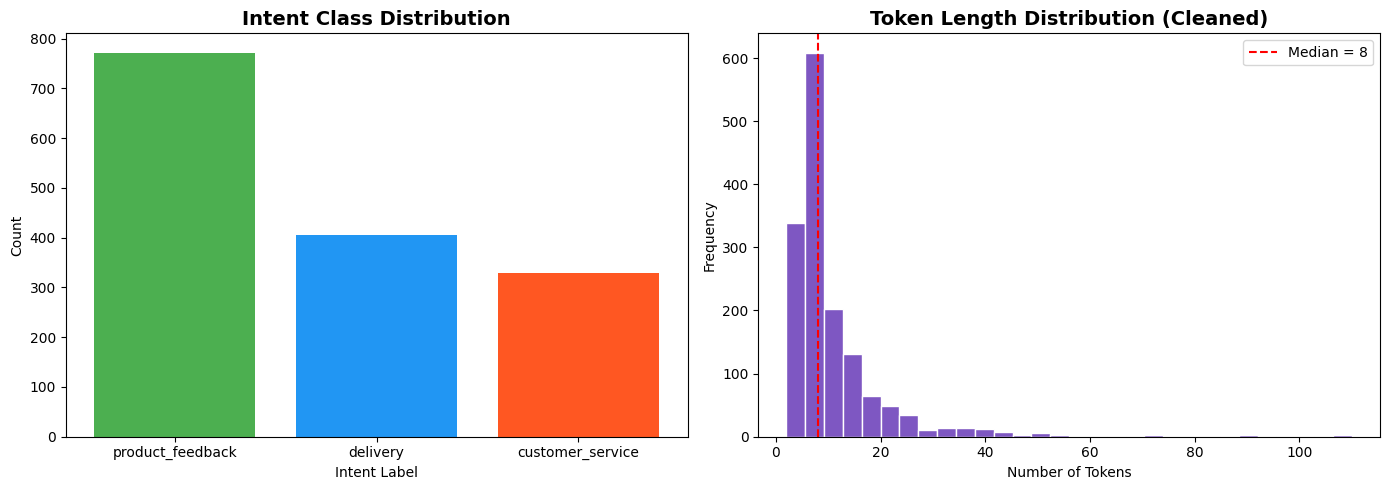


Token length stats after cleaning:
count    1507.00
mean       11.01
std        10.42
min         2.00
25%         6.00
50%         8.00
75%        12.00
max       110.00
Name: text_len, dtype: float64


/tmp/ipykernel_43787/3610575964.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_label, labels=labels_order, patch_artist=True,


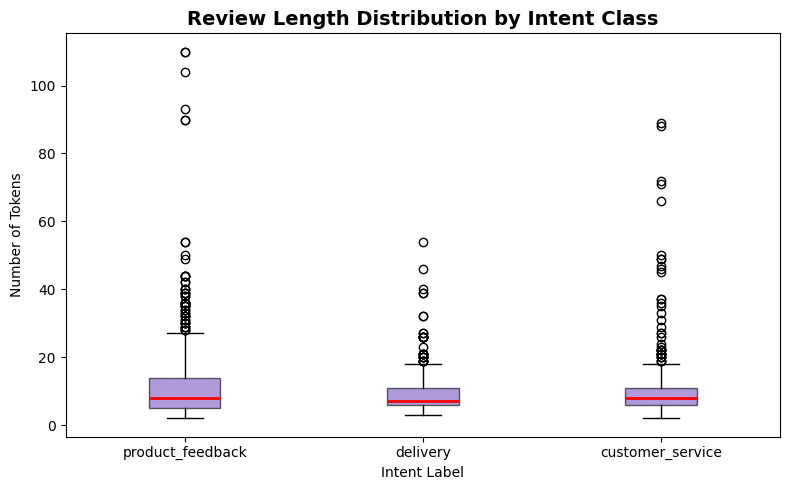

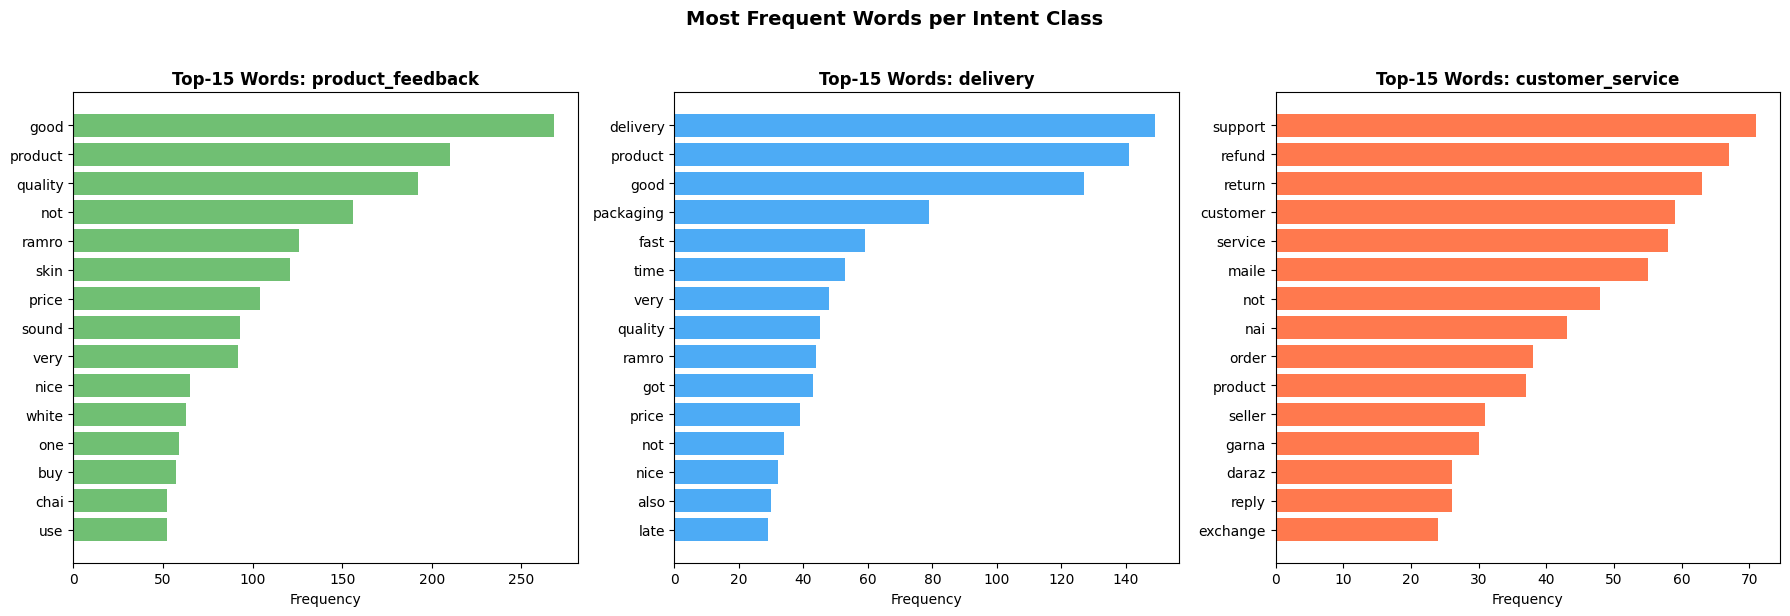

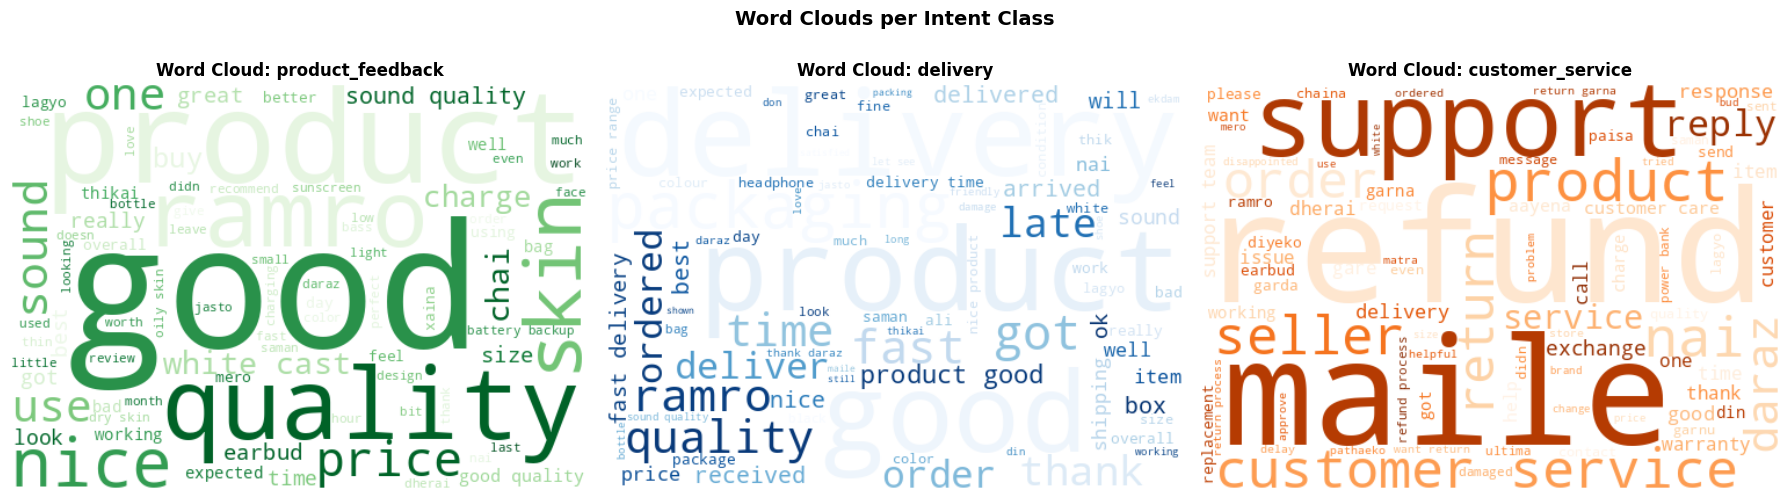

In [13]:
from collections import Counter
from wordcloud import WordCloud

# ── 1. Class distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#2196F3', '#FF5722'])
axes[0].set_title('Intent Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Intent Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# ── 2. Token length histogram ────────────────────────────────────────────
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split()))
axes[1].hist(df['text_len'], bins=30, color='#7E57C2', edgecolor='white')
axes[1].axvline(df['text_len'].median(), color='red', linestyle='--',
                label=f"Median = {df['text_len'].median():.0f}")
axes[1].set_title('Token Length Distribution (Cleaned)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Tokens')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('\nToken length stats after cleaning:')
print(df['text_len'].describe().round(2))

# ── 3. Review length box plot by label ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
labels_order = df['label'].unique().tolist()
data_by_label = [df[df['label'] == lbl]['text_len'].values for lbl in labels_order]
bp = ax.boxplot(data_by_label, labels=labels_order, patch_artist=True,
                boxprops=dict(facecolor='#7E57C2', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Review Length Distribution by Intent Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent Label')
ax.set_ylabel('Number of Tokens')
plt.tight_layout()
plt.savefig('length_boxplot.png', dpi=150)
plt.show()

# ── 4. Top-15 words per class ────────────────────────────────────────────
fig, axes = plt.subplots(1, len(labels_order), figsize=(18, 6))
colors = ['#4CAF50', '#2196F3', '#FF5722']
for ax, lbl, color in zip(axes, labels_order, colors):
    tokens = ' '.join(df[df['label'] == lbl]['clean_text']).split()
    top15 = Counter(tokens).most_common(15)
    words, freqs = zip(*top15)
    ax.barh(words[::-1], freqs[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top-15 Words: {lbl}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.suptitle('Most Frequent Words per Intent Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_words_per_class.png', dpi=150)
plt.show()

# ── 5. Word clouds per class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, len(labels_order), figsize=(18, 5))
wc_colors = ['Greens', 'Blues', 'Oranges']
for ax, lbl, cmap in zip(axes, labels_order, wc_colors):
    text = ' '.join(df[df['label'] == lbl]['clean_text'])
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud: {lbl}', fontsize=12, fontweight='bold')
plt.suptitle('Word Clouds per Intent Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()


---
# STEP 2 — Word2Vec Embedding Training

**Goals:**
- Tokenize the cleaned reviews
- Train a Word2Vec model (CBOW) on the corpus
- Build a word-to-index mapping and an embedding matrix for Keras
- Save `word2vec_daraz.model`, `embedding_matrix.npy`, `word2idx.pkl`

| Hyperparameter | Value | Reason |
|---|---|---|
| `vector_size` | 100 | Good for small datasets |
| `window` | 5 | Context window |
| `min_count` | 1 | Include all words (small corpus) |
| `sg` | 0 (CBOW) | Faster, works well on small data |
| `epochs` | 100 | More iterations → better embeddings |

In [14]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import pickle

print("Imports loaded.")

Imports loaded.


### 2.1 Load Cleaned Data & Tokenize

In [15]:
df = pd.read_csv("daraz_cleaned.csv")
print(f"Loaded {len(df)} cleaned reviews")

# Each review → list of words (Word2Vec input format)
sentences = [text.split() for text in df['clean_text'].tolist()]

print(f"\nSample tokens from first review: {sentences[0]}")
print(f"Total sentences : {len(sentences)}")
all_words = [w for s in sentences for w in s]
print(f"Total tokens    : {len(all_words)}")
print(f"Unique tokens   : {len(set(all_words))}")

Loaded 1507 cleaned reviews

Sample tokens from first review: ['saama', 'thikai', 'ota', 'magayeko', 'euta', 'problem', 'raixa', 'euta', 'ramro']
Total sentences : 1507
Total tokens    : 16596
Unique tokens   : 3167


### 2.2 Train Word2Vec Model

In [16]:
VECTOR_SIZE = 100   # embedding dimension — must match LSTM input_dim
WINDOW      = 5     # context window
MIN_COUNT   = 1     # include all words (small dataset)
SG          = 0     # 0 = CBOW, 1 = Skip-gram
EPOCHS      = 100

print(f"Training Word2Vec...")
print(f"  vector_size={VECTOR_SIZE}, window={WINDOW}, "
      f"min_count={MIN_COUNT}, mode={'Skip-gram' if SG else 'CBOW'}, epochs={EPOCHS}")

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    sg=SG,
    workers=4,
    epochs=EPOCHS,
    seed=42
)

vocab_size = len(w2v_model.wv)
print(f"\n✓ Word2Vec trained — Vocabulary size: {vocab_size}")

Training Word2Vec...
  vector_size=100, window=5, min_count=1, mode=CBOW, epochs=100

✓ Word2Vec trained — Vocabulary size: 3167


### 2.3 Test the Embeddings

In [17]:
print("Testing embeddings — most similar words:")
test_words = ['delivery', 'product', 'ramro', 'price', 'quality', 'service']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"  '{word}' → similar: {similar}")
    else:
        print(f"  '{word}' → not in vocabulary")

Testing embeddings — most similar words:
  'delivery' → similar: [('sam', 0.6590813994407654), ('aj', 0.6402513980865479), ('dhere', 0.6311172842979431)]
  'product' → similar: [('wow', 0.5438004732131958), ('value', 0.5436816811561584), ('advertised', 0.533647358417511)]
  'ramro' → similar: [('socheko', 0.7808813452720642), ('paunu', 0.7561702728271484), ('tapai', 0.7376658916473389)]
  'price' → similar: [('ignorable', 0.7355886101722717), ('valued', 0.7333694696426392), ('cons', 0.7282424569129944)]
  'quality' → similar: [('matters', 0.6564713716506958), ('indeed', 0.6528586149215698), ('price', 0.6225837469100952)]
  'service' → similar: [('care', 0.8018670082092285), ('banaucha', 0.7841637134552002), ('blamed', 0.7736890316009521)]


### 2.4 Build Embedding Matrix for Keras

- **`word2idx`**: maps each word → integer index (index 0 reserved for `<PAD>`)
- **`embedding_matrix`**: shape `(vocab_size+1, vector_size)` — row `i` = Word2Vec vector for word at index `i`

In [18]:
# word → index (1-indexed; 0 is reserved for padding)
word2idx = {word: idx + 1 for idx, word in enumerate(w2v_model.wv.index_to_key)}

# Embedding matrix: row 0 = zeros (padding), row i = Word2Vec vector
embedding_matrix = np.zeros((vocab_size + 1, VECTOR_SIZE))
for word, idx in word2idx.items():
    embedding_matrix[idx] = w2v_model.wv[word]

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"  Row 0  → padding vector (all zeros)")
print(f"  Row 1  → vector for '{w2v_model.wv.index_to_key[0]}'")

Embedding matrix shape : (3168, 100)
  Row 0  → padding vector (all zeros)
  Row 1  → vector for 'good'


### 2.5 Save Artifacts

In [19]:
w2v_model.save("../models/word2vec_daraz.model")
np.save("embedding_matrix.npy", embedding_matrix)

with open("word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)

print("Saved artifacts:")
print("  ✓ word2vec_daraz.model")
print("  ✓ embedding_matrix.npy")
print("  ✓ word2idx.pkl")
print(f"\nVOCAB_SIZE  = {vocab_size}  (use in LSTM Embedding layer)")
print(f"VECTOR_SIZE = {VECTOR_SIZE}  (embedding_dim in LSTM)")

Saved artifacts:
  ✓ word2vec_daraz.model
  ✓ embedding_matrix.npy
  ✓ word2idx.pkl

VOCAB_SIZE  = 3167  (use in LSTM Embedding layer)
VECTOR_SIZE = 100  (embedding_dim in LSTM)


### 2.6 Word2Vec Analysis — Semantic Similarity & Embedding Visualization

Demonstrates that Word2Vec learned meaningful relationships from the Daraz corpus.

=== Semantic Similarity Demo ===

  'delivery' → similar: ['sam', 'aj', 'dhere', 'layoo', 'itema']

  'product' → similar: ['wow', 'value', 'advertised', 'boards', 'budget']

  'ramro' → similar: ['socheko', 'paunu', 'tapai', 'dhukka', 'hamile']

  'price' → similar: ['ignorable', 'valued', 'cons', 'range', 'enc']

  'return' → similar: ['arrange', 'bhayepani', 'pickup', 'blender', 'leko']

  'quality' → similar: ['matters', 'indeed', 'price', 'enc', 'music']

  'service' → similar: ['care', 'banaucha', 'blamed', 'questioned', 'cross']

t-SNE: plotting 29 words across 3 categories


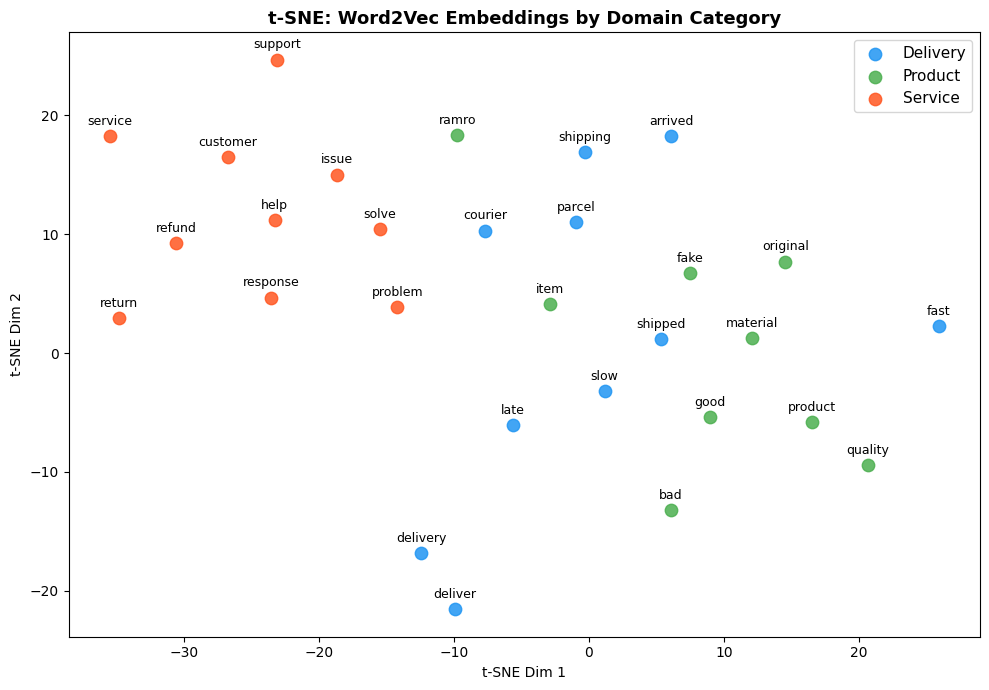

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ── most_similar() demo ──────────────────────────────────────────────────
print('=== Semantic Similarity Demo ===')
probe_words = ['delivery', 'product', 'ramro', 'price', 'return', 'quality', 'service']
for word in probe_words:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}' → similar: {[w for w,_ in sims]}")
    else:
        print(f"\n  '{word}' not in vocabulary — skipping")

# ── t-SNE 2D embedding plot ──────────────────────────────────────────────
# Manually curated word categories (domain-relevant for Daraz reviews)
word_categories = {
    'Delivery': ['delivery', 'deliver', 'shipping', 'shipped', 'arrived',
                 'courier', 'parcel', 'fast', 'slow', 'late'],
    'Product':  ['product', 'quality', 'original', 'fake', 'good', 'bad',
                 'ramro', 'kharab', 'item', 'material'],
    'Service':  ['service', 'support', 'response', 'return', 'refund',
                 'customer', 'help', 'issue', 'problem', 'solve'],
}

# Build word list, skipping any not in vocab
plot_words, plot_vectors, plot_labels = [], [], []
for cat, words in word_categories.items():
    for w in words:
        if w in w2v_model.wv:
            plot_words.append(w)
            plot_vectors.append(w2v_model.wv[w])
            plot_labels.append(cat)

print(f"\nt-SNE: plotting {len(plot_words)} words across {len(word_categories)} categories")

if len(plot_words) >= 5:
    perplexity = min(5, len(plot_words) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity,
                max_iter=1000, init='pca')
    coords = tsne.fit_transform(np.array(plot_vectors))

    cat_colors = {'Delivery': '#2196F3', 'Product': '#4CAF50', 'Service': '#FF5722'}
    fig, ax = plt.subplots(figsize=(10, 7))
    for cat in word_categories:
        idx = [i for i, l in enumerate(plot_labels) if l == cat]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=cat_colors[cat], label=cat, s=80, alpha=0.85)
        for i in idx:
            ax.annotate(plot_words[i], (coords[i, 0], coords[i, 1]),
                        fontsize=9, ha='center', va='bottom',
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(fontsize=11)
    ax.set_title('t-SNE: Word2Vec Embeddings by Domain Category', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    plt.tight_layout()
    plt.savefig('tsne_embeddings.png', dpi=150)
    plt.show()
else:
    print('Not enough words found in vocabulary for t-SNE. Try running after training.')


---
#  STEP 3 — Sequence Preparation + Bidirectional LSTM Training

**Goals:**
- Convert text to padded integer sequences
- One-hot encode labels
- Split into train / validation / test sets (70 / 15 / 15)
- Build and train a Bidirectional LSTM with pretrained Word2Vec weights
- Evaluate and visualize results

**Architecture:**
```
Embedding (Word2Vec, frozen)
  → SpatialDropout1D(0.3)
  → Bidirectional LSTM(128, dropout=0.2)
  → Dense(64, relu)
  → Dropout(0.4)
  → Dense(NUM_CLASSES, softmax)
```
> **Why Bidirectional?** Romanized Nepali has flexible word order — bi-directional context helps capture meaning from both sides of each word.

In [62]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1774886279.672592   71776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774886279.675799   71776 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774886280.318958   71776 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774886283.302359   71776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0


### 3.1 Load Artifacts

In [2]:
df = pd.read_csv("daraz_cleaned.csv")
embedding_matrix = np.load("embedding_matrix.npy")

with open("word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

VOCAB_SIZE   = embedding_matrix.shape[0] - 1
VECTOR_SIZE  = embedding_matrix.shape[1]
NUM_CLASSES  = df['label'].nunique()

print(f"Vocab size        : {VOCAB_SIZE}")
print(f"Embedding dim     : {VECTOR_SIZE}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Classes           : {df['label'].unique()}")

Vocab size        : 2828
Embedding dim     : 100
Number of classes : 3
Classes           : <StringArray>
['product_feedback', 'delivery', 'customer_service']
Length: 3, dtype: str


### 3.2 Determine MAX_LEN & Convert to Padded Sequences

In [3]:
# Use 95th percentile of token lengths as MAX_LEN
lengths = df['clean_text'].apply(lambda x: len(x.split()))
MAX_LEN = int(np.percentile(lengths, 95))
print(f"95th percentile token length → MAX_LEN = {MAX_LEN}")

def text_to_sequence(text, word2idx):
    """Map each word to its index; unknown words → 0 (padding index)."""
    return [word2idx.get(word, 0) for word in text.split()]

X_sequences = [text_to_sequence(text, word2idx) for text in df['clean_text']]
X = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X shape after padding : {X.shape}")

95th percentile token length → MAX_LEN = 40
X shape after padding : (1033, 40)


### 3.3 Encode Labels (One-Hot)

In [4]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['label'])
y = tf.keras.utils.to_categorical(y_encoded, num_classes=NUM_CLASSES)

print(f"y shape (one-hot) : {y.shape}")

y shape (one-hot) : (1033, 3)


### 3.4 Train / Validation / Test Split (70 / 15 / 15)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(f"Split sizes:")
print(f"  Train : {X_train.shape[0]}")
print(f"  Val   : {X_val.shape[0]}")
print(f"  Test  : {X_test.shape[0]}")

Split sizes:
  Train : 723
  Val   : 155
  Test  : 155


### 3.5 Build the Bidirectional LSTM Model

In [ ]:
def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE + 1,
            output_dim=VECTOR_SIZE,
            weights=[embedding_matrix],
            input_length=MAX_LEN,
            trainable=False
        ),

        SpatialDropout1D(0.3),

        # 🔼 LSTM STACK (bigger + deeper)
        Bidirectional(LSTM(
            128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2
        )),

        Bidirectional(LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )),

        # 🔼 Bigger dense layers
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=5e-4),   # slightly lower LR for stability
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_lstm_model()
model.summary()

/home/roshan/Documents/TIC_LSTM/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1774844351.438276   40468 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
I0000 00:00:1774844351.438422   40468 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1774844351.438467   40468 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: Roshan
I0000 00:00:1774844351.438480   40468 cuda_diagnostics.cc:183] hostname: Roshan
I0000 00:00:1774844351.438893   40468 cuda_diagnostics.cc:190] libcuda reported version is: 535.288.1
I0000 00:00:1774844351.438945   40468 cuda_diagnostics.cc:194] kerne

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       282,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,900 (1.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 282,900 (1.08 MB)

### 3.6 Define Callbacks

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='../models/large_lstm_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
BATCH_SIZE = 32
EPOCHS     = 50   # EarlyStopping will stop earlier if needed

print("Training LSTM model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

### 3.8 Evaluate on Test Set

In [ ]:
print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

### 3.9 Training Curves & Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curves
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curves
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Plots saved: training_curves.png, confusion_matrix.png")
print("Best model : ../models/large_lstm_model.h5")

---
#  STEP 4 — Inference: Predict Intent from New Reviews

**Goals:**
- Load the saved model and all artifacts
- Apply the same preprocessing pipeline
- Predict intent with confidence scores for new Romanized Nepali reviews
- Run a batch of test examples
- (Optional) Interactive prediction loop

In [ ]:
import numpy as np
import pickle
import re
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("Imports loaded.")

### 4.1 Load Saved Artifacts

In [ ]:
model = tf.keras.models.load_model("../models/large_lstm_model.h5")

with open("word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

# Reconstruct label encoder from training data
df = pd.read_csv("daraz_cleaned.csv")
label_encoder = LabelEncoder()
label_encoder.fit(df['label'])

# Must match MAX_LEN used during training
MAX_LEN = int(np.percentile(df['clean_text'].apply(lambda x: len(x.split())), 95))

print("✓ Model, word2idx, and label encoder loaded.")
print(f"  MAX_LEN        : {MAX_LEN}")
print(f"  Intent classes : {list(label_encoder.classes_)}")

### 4.2 Preprocessing & Prediction Functions

> ️ The preprocessing here **must be identical** to the pipeline used in Step 1.

In [ ]:
# ── Define stopwords for inference (must match training) ────────────────
ROMANIZED_NEPALI_STOPWORDS = {
    # numbers
    'ek','dui','teen','tin','char','paanch','panch','chha','saat','sata','ath','nau',
    # question / filler particles
    'ke','ta','uta','ni','na','hai','ho','taki',
    # copula / auxiliary verbs
    'xa','cha','chhan','xan','chan',
    'thiyo','thiye','thyo','thhiyo',
    'bhayo','vayo','bayo','vhayo',
    'aayo','ayo',
    'garyo','gareko','garcha','garxa','garne','gari','garera',
    'huncha','hunxa','hucha','hune','hun',
    # conjunctions / prepositions
    'pani','ra','ani','tara',
    'ko','ma','le','bata','baata','lai','laai','lagi','laghi',
    # pronouns / demonstratives
    'yo','yas','yahi','tyo','tyas','tyahi',
}

ENGLISH_STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves',
    'you','your','yours','yourself','yourselves',
    'he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those',
    'am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while',
    'of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from',
    'up','down','in','out','on','off','over','under','further',
    'then','once','here','there','when','where','why','how',
    'all','any','both','each','few','most','other','such',
    'only','own','so','st','now',
}

ALL_STOPWORDS = ROMANIZED_NEPALI_STOPWORDS | ENGLISH_STOPWORDS

def preprocess_input(text):
    """Apply the EXACT same cleaning pipeline as training (Step 1)."""
    if not isinstance(text, str):
        return ""
    
    # 1. Remove HTML
    text = re.sub('<.*?>', ' ', text)
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # 3. Remove emojis
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    
    # 4. Lowercase
    text = text.lower()
    
    # 5. Keep only letters, digits, spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # 6. Remove standalone numbers
    text = re.sub(r'\b\d+\b', '', text)
    
    # 7. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 8. Remove stopwords (CRITICAL: must match training!)
    tokens = text.split()
    filtered = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 1]
    text = ' '.join(filtered)
    
    return text



def predict_intent(review_text, threshold=0.5):
    """
    Predict the intent of a raw review string.

    Returns:
        intent_label   : predicted class (or 'uncertain' if confidence < threshold)
        confidence     : probability of the predicted class
        all_probs_dict : probabilities for all classes
    """
    clean = preprocess_input(review_text)
    if not clean:
        return "unknown", 0.0, {}

    sequence = [word2idx.get(word, 0) for word in clean.split()]
    padded   = pad_sequences([sequence], maxlen=MAX_LEN, padding='post', truncating='post')

    probs      = model.predict(padded, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    confidence = float(probs[pred_idx])
    label      = label_encoder.classes_[pred_idx]

    all_probs = {
        label_encoder.classes_[i]: round(float(p), 4)
        for i, p in enumerate(probs)
    }

    if confidence < threshold:
        label = "uncertain"

    return label, confidence, all_probs


print("predict_intent() function ready.")

### 4.3 Batch Prediction — Sample Reviews

In [ ]:
test_reviews = [
    # Delivery intent
    "delivery ekdam late bhayo, 2 hapta lagyo",
    "fast delivery dherai ramro packaging",
    # Product feedback intent
    "product quality ekdam ramro xa, price pani thikai cha",
    "quality sasto thiyo, second day ma break bhayo",
    # Customer service intent
    "return garnai pardaina customer service respond gardaina",
    "Got the product but it is not working, need return please",
    # Mixed / edge cases
    "nice product fast delivery good service",
    "radd chha yesto product naliw hai"
]

print("=" * 65)
print("INTENT PREDICTION — SAMPLE ROMANIZED NEPALI REVIEWS")
print("=" * 65)

results = []
for review in test_reviews:
    intent, conf, all_probs = predict_intent(review)
    results.append({
        'review': review,
        'intent': intent,
        'confidence': f"{conf:.2%}",
        **{f'p({k})': v for k, v in all_probs.items()}
    })
    print(f"\nReview   : {review}")
    print(f"Intent   : {intent}  (confidence: {conf:.2%})")
    print(f"All probs: {all_probs}")

# Display as a clean DataFrame
print("\n" + "=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
pd.DataFrame(results)[['review', 'intent', 'confidence']]

### 4.4 Interactive Prediction

Run the cell below to interactively type Romanized Nepali reviews and get instant intent predictions. Type `quit` to exit.

In [ ]:
print("=" * 60)
print("INTERACTIVE MODE — type 'quit' to exit")
print("=" * 60)

while True:
    user_input = input("\nEnter review: ").strip()
    if user_input.lower() in ('quit', 'exit', 'q', ''):
        print("Exiting interactive mode.")
        break
    intent, conf, all_probs = predict_intent(user_input)
    print(f"  → Intent     : {intent}")
    print(f"  → Confidence : {conf:.2%}")
    print(f"  → All scores : {all_probs}")

---
## ✅ Pipeline Summary

| Artifact | Description |
|---|---|
| `daraz_cleaned.csv` | Preprocessed reviews with `clean_text` and `label_encoded` columns |
| `word2vec_daraz.model` | Trained Word2Vec model (100-dim, CBOW, 100 epochs) |
| `embedding_matrix.npy` | Numpy embedding matrix for Keras Embedding layer |
| `word2idx.pkl` | Word → integer index mapping |
| `large_lstm_model.h5 | Best Bidirectional LSTM model checkpoint |
| `class_distribution.png` | Class distribution & token length plots |
| `training_curves.png` | Accuracy & loss curves over epochs |
| `confusion_matrix.png` | Confusion matrix on the test set |

**To run on new data:**  
1. Place your new CSV at the path expected in Step 1  
2. Run Steps 1–3 to retrain, **or**  
3. Skip directly to Step 4 — just load `large_lstm_model.h5` + `word2idx.pkl` and call `predict_intent()`